# **Instruções**
1. Esta avaliação deve ser feita de duas a três pessoas.
2. Data de entrega: 07/09/2026 até 18:59. Trabalhos não podem ser entregues em atraso.
3. Esta avaliação tem por objetivo consolidar o aprendizado sobre reconhecimento de imagem e processamento
digital de imagens. Cópias acarretam em zero para todos os envolvidos.
4. A implementação deverá ser desenvolvida em Python. O uso de funções de filtragem ou operações pontuais
prontas de bibliotecas não serão aceitas. Todos os códigos implementados estão passíveis de ser explicados,
independente da origem.
5. O dataset está no seguinte link: https://github.com/VielF/ColabProjects/tree/main/dataset/ImgTrabM1
6. O sistema deve ser entregue funcionando corretamente em formato de Jupyter notebook.
7. Deve ser disponibilizado os códigos da implementação juntamente com a relatório (salvo o caso da
disponibilidade em repositório aberto do aluno, que deve ser fornecido o link). O repositório deve estar aberto
do momento da entrega em diante, sendo que o professor não responsabiliza caso o projeto não esteja
disponível para consulta no momento da correção, sendo do(s) aluno(s) essa responsabilidade de manter
disponível.
8. A não entrega e apresentação (caso solicitado) do trabalho acarretará nota zero para todos os integrantes.
Todos os integrantes deverão ter conhecimento de todas as partes da implementação. O integrante que não
apresentar (caso solicitado), terá sua nota zerada no quesito apresentação. Todos os alunos deverão
responder os questionamentos na apresentação, porém fica a cargo do professor escolher um representante
que explicar pelo grupo.
9. Postar Respositório/Jupyte Notebook/Código no material da disciplina.
10. Cada individuo/dupla/trio terá de 10 à 15 minutos para apresentar (caso solicitado) seu desenvolvimento. O
processamento estará passível de ser testada com qualquer imagem no momento da apresentação.

# **Projeto Desenvolvido**

In [1]:
"""SETUP INICIAL"""
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

## 1. **Manipulação de Pixels**
a. Escreva uma função que receba uma imagem colorida e determine a cor que ocorre com maior
frequência na imagem.

b. Escreva uma função denominada mergeImage que receba duas imagens, fg e bg, extraia o objeto em
primeiro plano e o insira no plano de fundo, retornando a imagem resultante.

c. Teste a função utilizando diferentes imagens de primeiro plano e de plano de fundo, à sua escolha, e
apresente os resultados.

In [ ]:
def cor_mais_frequente(imagem):
    """Recebe uma imagem e então determina a cor que aparece mais frequentemente na imagem"""
    hist = np.zeros((256, 256, 256), dtype=np.int64)
    for i in range(imagem.shape[0]):
        for j in range(imagem.shape[1]):
            # Histograma para cada canal de cor (Ordem CV2: B G R)
            b, g, r = imagem[i, j]
            hist[b, g, r] += 1

    # Obter maior valor e gerar valores RGB
    maior_valor_1d = np.argmax(hist)
    b, g, r = np.unravel_index(maior_valor_1d, hist.shape)
    total = imagem.shape[0] * imagem.shape[1]

    # Cor frequente e frequência
    return (b, g, r), hist[b, g, r] / total

def mergeImage(fg_img, bg_img, limiar = 30):
    """Recebe duas imagens, fg (foreground) e bg (background) e junta o objeto em fg com o fundo bg"""
    output_img = bg_img.copy()

    (cor_fundo, _) = cor_mais_frequente(fg_img)
    fg_height, fg_width = fg_img.shape[:2]
    bg_height, bg_width = bg_img.shape[:2]

    for y in range(fg_height):
        for x in range(fg_width):
            if y < 0 or y >= bg_height or x < 0 or x >= bg_width:
                # Pixel fora dos limites do fundo, ignorando
                continue

            # Conversão para evitar overflow/underflow na subtração
            pixel = fg_img[y, x].astype(int)

            # Cálculo da distância normalizada entre o pixel atual e a cor de fundo
            DIST_MAX = np.sqrt(3 * 255**2)
            dist = np.sqrt(np.sum((pixel - cor_fundo) ** 2)) / DIST_MAX * 100

            if dist > limiar:
                # Objeto, sobrescrevendo o pixel no fundo
                output_img[y, x] = fg_img[y, x]

    return output_img


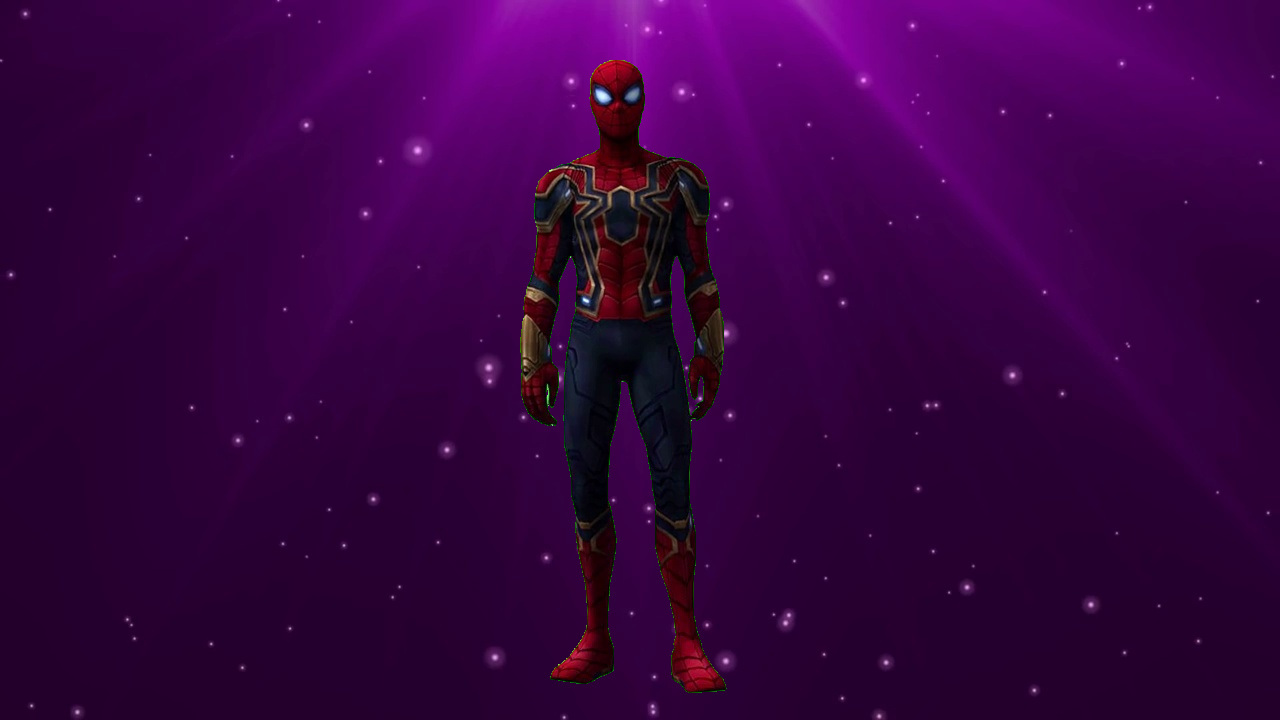

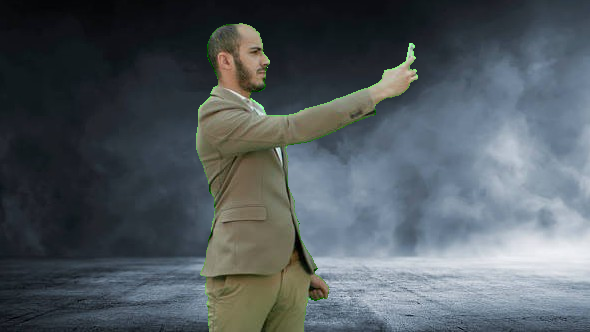

In [4]:
# Cor mais frequente
exercicio1_img = cv2.imread('data/fg1.jpg',1)
exercicio1_output1 = cor_mais_frequente(exercicio1_img)

# Merge image
exercicio1_fg = cv2.imread('data/fg.jpg',1)
exercicio1_bg = cv2.imread('data/bg.jpg',1)
exercicio1_output2 = mergeImage(exercicio1_fg, exercicio1_bg)

# Merge image 2
exercicio1_fg1 = cv2.imread('data/fg1.jpg',1)
exercicio1_bg1 = cv2.imread('data/bg1.jpg',1)
exercicio1_output3 = mergeImage(exercicio1_fg1, exercicio1_bg1)

cv2_imshow(exercicio1_output2)
cv2_imshow(exercicio1_output3)

## 2. **Manipulação de Bits**
a. Escreva uma função denominada BitQuantizeImage que receba uma imagem de 8 bits im e o valor k,correspondente ao número de bits para o qual a imagem deverá ser quantizada, e retorne a imagem quantizada em k bits. Apresente os resultados para a imagem quantize.jpg.

b. Escreva um código para exibir os diferentes planos de bits de uma imagem em tons de cinza de 8 bits. Apresente os resultados para a imagem cameraman.png.

c. Considerando a imagem original lena.jpg, identifique as operações aplicadas às imagens lena1.jpg, lena2.jpg e lena3.jpg.

## 3. **Questões Diversas**
a. O que se pode afirmar sobre o histograma de uma imagem resultante quando mantemos em 0 os bits MSB no plano de bits?
*   Resposta: ???

b. O que se pode afirmar sobre o histograma de uma imagem resultante quando mantemos em 0 os bits LSB no plano de bits?
*   Resposta: ???

c. A transmissão é geralmente realizada por meio de pacotes que contêm um bit de início, um byte de informação e um bit de parada. A taxa de transmissão (baud rate) é uma medida comum para a transmissão de dados digitais e é definida como o número de bits transmitidos por segundo. Quanto tempo seria necessário para transmitir uma imagem em tons de cinza de 512 x 512 pixels, com intensidades de 0 a 255, por meio de um enlace de 56K baud? Da mesma forma, calcule o tempo necessário para transmitir a
mesma imagem por meio de um enlace de 3000K baud.
*   Resposta: ???

## 4. **Transformação de Histograma**

a. Escolha uma imagem de sua preferência e aplique a equalização do histograma a ela. Em seguida, aplique novamente a equalização do histograma à imagem resultante e compare as duas imagens.
Quais são as suas observações?
*   Resposta: ???

b. Selecione as seguintes combinações de imagens e realize a transformação de histograma sobre elas.

*   Histogramas semelhantes
*   Imagem escura -> clara
*   Imagem clara -> escura

## 5. **Detecção de Bordas**
a. Aplique o detector de bordas de Canny (utilize cv2.Canny ou a função edge do MATLAB) às imagens bell.jpg e cubes.png. Ajuste os valores dos argumentos (minVal e maxVal) e informe os valores que produzem os melhores resultados para cada imagem.

*   Dica: para a imagem bell.jpg, procure detectar o maior número possível de bordas na campainha, evitando, ao mesmo tempo, as bordas presentes no plano de fundo.

b. Considere os filtros de Roberts, Prewitt e Sobel, bem como os filtros Laplacianos. Aplique esses filtros à imagem barbara.jpg e faça observações a partir da comparação entre suas saídas. Compare esses
resultados com a saída do detector de bordas de Canny aplicado à mesma imagem.

c. Adicione ruído à imagem de entrada acima utilizando amostragem gaussiana. Analise o efeito da aplicação
dos filtros sobre as imagens afetadas pelo ruído.

## 6. **Filtragem High-Boost**
a. Implemente a filtragem high-boost na imagem bell.jpg, variando o tamanho da janela e o fator de ponderação, e relate suas observações.

b. Repita o exercício anterior utilizando imagens adequadas de sua escolha.

c. Em que a filtragem bilateral se diferencia da filtragem high-boost?
*   Resposta: ???

## 7. **Filtragem Bilateral**
a. Implemente um filtro bilateral e aplique-o às imagens sky.png e noir.png.

b. Varie o efeito dos componentes espacial (domain) e de intensidade (range) do filtro bilateral e procure minimizar a distância L2 em relação às imagens de referência (ground truth). Exiba as imagens e os valores
aproximados de sigma.